## Additional visualization for one-way rectangle
The following notebook generates the Density Evolution Plot for the **Rectangular Road (with constant velocity)**.

#### Import Statements

In [13]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

#### Visualization Font Adjustment

In [14]:
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

#### Initializing Parameters and Path

In [15]:
# ==============================
# Simulation Parameters
# ==============================
T = 3.0
nSteps = 300

# ==============================
# Traffic Visualization Parameters
# ==============================
xmin = 0.0
xmax = 30.0

# Generates array of color values
colors = plt.cm.turbo(np.linspace(0, 1, 30))

# ==============================
# Modulo Selection
# ==============================
plot_modulo = 10

# ==============================
# Data Path
# ==============================
data_path = "oneway_rect_output"

#### Collection of Files
The following obtains the '.dat' files that contain density values at points (x,y).

In [16]:
pattern = re.compile(r"density_k_(\d+)\.dat")

files = []
for filename in os.listdir(data_path):
    match = pattern.match(filename)
    if match:
        k = int(match.group(1))
        files.append((k, filename))

files.sort(key=lambda x: x[0])

if not files:
    raise RuntimeError("No density_k_*.dat files found in the directory.")

#### Density Evolution Plots
Generates a graph showing the evolution of traffic density on the road at specific timestamps, decided by `plot_modulo`.

##### Taking x-position:

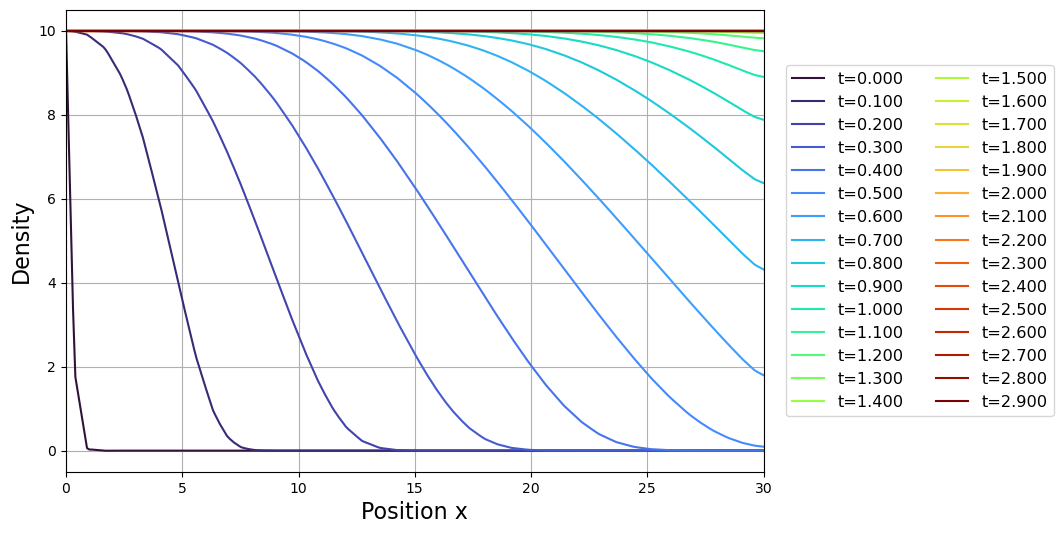

Density evolution plot saved to: oneway_rect_output\density_evolution_xaxis_mod_10.png


In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

for k, filename in files:
    if k % plot_modulo != 0:
        continue

    t_k = (k / nSteps) * T

    full_path = os.path.join(data_path, filename)
    data = np.loadtxt(full_path)

    x = data[:, 0]
    rho = data[:, 2]

    i = int(k/10)

    ax.plot(x, rho, label=f"t={t_k:.3f}", color=colors[i])

ax.set_xlabel("Position x")
ax.set_xlim(xmin,xmax)
ax.set_ylabel("Density")
ax.grid(True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=2, fontsize='small')

output_file = os.path.join(
    data_path,
    f"density_evolution_xaxis_mod_{plot_modulo}.png"
)
plt.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Density evolution plot saved to: {output_file}")

##### Taking y-position:

Because the road is mainly horizontal, taking the evolution plot over the y-axis is not necessary.